In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
data = pd.read_csv("buggy_alfalfa.csv")

In [42]:
data.columns

Index(['field='field',layer_index='0'.water_content.values',
       'field='field',layer_index='0'.nitrate_content.values',
       'field='field',layer_index='1'.water_content.values',
       'field='field',layer_index='1'.nitrate_content.values',
       'field='field',layer_index='2'.water_content.values',
       'field='field',layer_index='2'.nitrate_content.values',
       'field='field',layer_index='3'.water_content.values',
       'field='field',layer_index='3'.nitrate_content.values',
       'field='field',layer_index='4'.water_content.values',
       'field='field',layer_index='4'.nitrate_content.values',
       'Time.day.values', 'Time.year.values', 'Time.calendar_year.values',
       'field='field',crop='default alfalfa',planted=105,2014.biomass.values',
       'field='field',crop='default alfalfa',planted=105,2014.biomass_growth_max.values',
       'field='field',crop='default alfalfa',planted=105,2014.biomass_growth.values',
       'field='field',crop='default alfalfa',plant

In [43]:
days = data["Time.day.values"].dropna().tolist()
years = data["Time.calendar_year.values"].dropna().tolist()
dates = [f"{day}/{year}" for day, year in zip(days, years) if not (day < 106 and year == 2014) and  not (246 < day and year == 2016)]

In [44]:
total_biomass = data["field='field',crop='default alfalfa',planted=105,2014.biomass.values"].dropna().tolist()
print(len(total_biomass))
biomass_increase = data["field='field',crop='default alfalfa',planted=105,2014.biomass_growth.values"].dropna().tolist()
biomass_increase.insert(0, 0)
surface_biomass = data["field='field',crop='default alfalfa',planted=105,2014.above_ground_biomass.values"].dropna().tolist()
root_biomass = data["field='field',crop='default alfalfa',planted=105,2014.root_biomass.values"].dropna().tolist()
root_biomass.insert(0, 0)

871


In [45]:
zipped_surface_root_biomasses = list(zip(surface_biomass, root_biomass))
surface_root_biomasses = [mass[0] + mass[1] for mass in zipped_surface_root_biomasses]

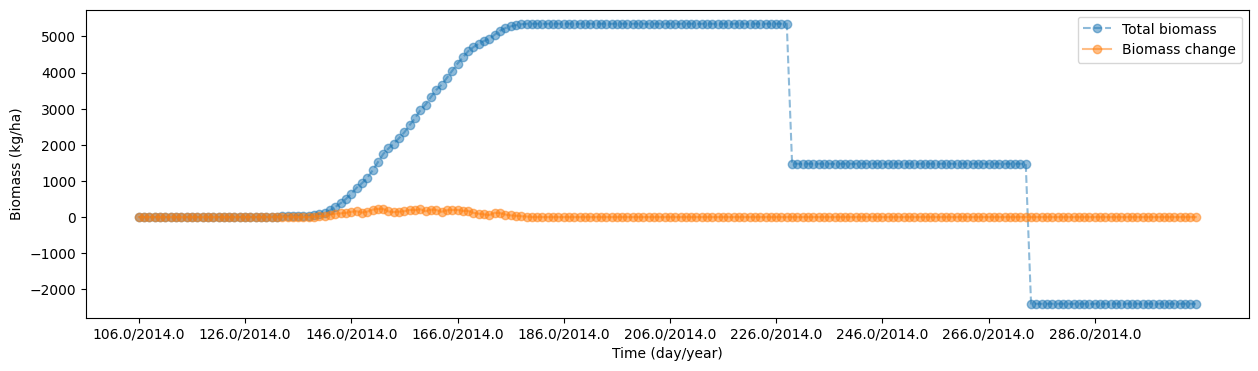

In [46]:
start_day = 0
end_day = 200
x = dates[start_day:end_day]
biomass = total_biomass[start_day:end_day]
increase = biomass_increase[start_day:end_day]
num_ticks = int((end_day - start_day) / 10)
x_ticks = x[::num_ticks]
plt.figure(figsize=(15, 4))
plt.plot(x, biomass, "o--", alpha=0.5)
plt.plot(x, increase, "o-", alpha=0.5)
plt.xticks(x_ticks)
plt.xlabel("Time (day/year)")
plt.ylabel("Biomass (kg/ha)")
plt.legend(["Total biomass", "Biomass change"])
plt.show()

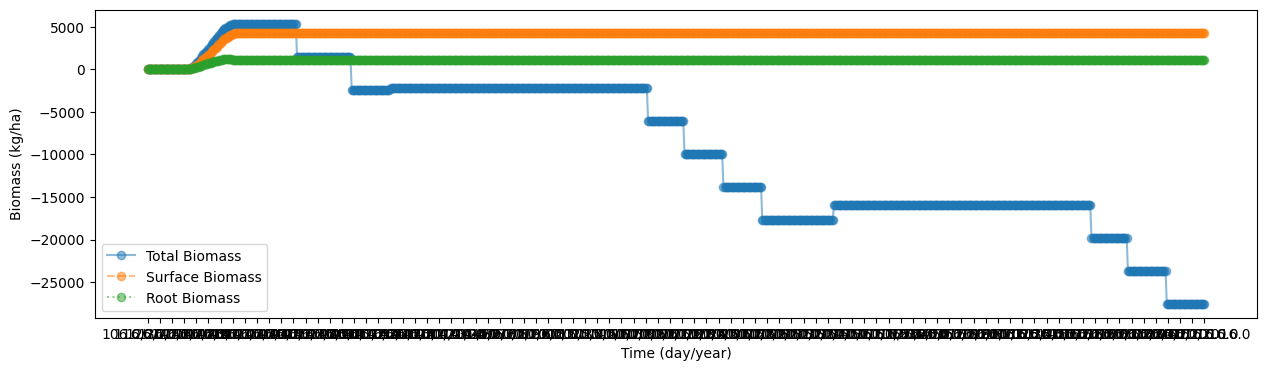

In [47]:
x = dates
x_ticks = x[::10]
plt.figure(figsize=(15, 4))
plt.plot(x, total_biomass, "o-", alpha=0.5)
plt.plot(x, surface_biomass, "o--", alpha=0.5)
plt.plot(x, root_biomass, "o:", alpha=0.5)
plt.xlabel("Time (day/year)")
plt.ylabel("Biomass (kg/ha)")
plt.legend(["Total Biomass", "Surface Biomass", "Root Biomass"])
plt.xticks(x_ticks)
plt.show()

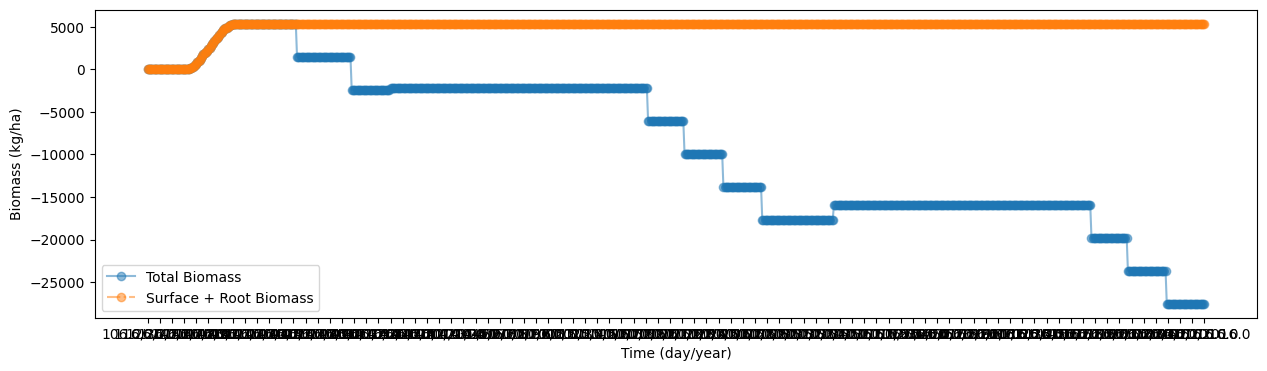

In [48]:
x = dates
x_ticks = x[::10]
plt.figure(figsize=(15, 4))
plt.plot(x, total_biomass, "o-", alpha=0.5)
plt.plot(x, surface_root_biomasses, "o-.", alpha=0.5)
plt.xticks(x_ticks)
plt.xlabel("Time (day/year)")
plt.ylabel("Biomass (kg/ha)")
plt.legend(["Total Biomass", "Surface + Root Biomass"])
plt.show()